# 03 PantauPadi Modeling

Notebook ini digunakan untuk membangun model machine learning PantauPadi.

**Tujuan modeling:**
Memprediksi , yaitu risiko gangguan panen padi pada bulan berikutnya berdasarkan fitur iklim bulan berjalan, sensitivitas historis wilayah, serta fitur lag/rolling.


**Output:**
- Evaluasi Logistic Regression
- Evaluasi Random Forest
- Perbandingan model
- Feature importance
- File prediksi bulan depan

## 1. Konsep Modeling PantauPadi

Dalam proyek ini, `sifat_hujan` bukan target akhir. `sifat_hujan` adalah kategori hujan dari BMKG seperti AN, N, dan BN.

Target akhir model adalah:

`risk_label_bulan_depan`

Artinya, model belajar dari kondisi bulan ini untuk memprediksi risiko pada bulan berikutnya.

Alur sederhananya:

```text
Fitur bulan ini + histori wilayah + pola lag/rolling
↓
Model machine learning
↓
Prediksi risiko bulan depan: low / medium / high
```

Model yang digunakan:
1. **Logistic Regression** sebagai baseline machine learning.
2. **Random Forest** sebagai model non-linear pembanding.

Evaluasi dilakukan menggunakan:
- Accuracy
- Macro F1-score
- Precision, recall, F1 per kelas
- Confusion matrix

Dalam konteks early warning, kita tidak hanya mengejar accuracy. Kita juga melihat apakah model mampu mengenali kelas `high`, karena kelas ini penting untuk prioritas pemantauan.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_recall_fscore_support
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 2. Load Dataset Modeling

Upload file `pantaupadi_modeling_table_final.csv` ke Colab terlebih dahulu.

File ini adalah hasil dari tahap feature engineering dan sudah berisi:
- fitur iklim,
- skor risiko,
- fitur historis wilayah,
- fitur lag/rolling,
- target `risk_label_bulan_depan`.

In [ ]:

from google.colab import drive
drive.mount('/content/drive')
import os

modeling_path = 'pantaupadi_modeling_table_final.csv'

path = "/content/drive/MyDrive/collab/pantaupadi"

# Berpindah ke folder tersebut
os.chdir(path)

# Cek apakah file-file yang kamu butuhkan sudah terlihat
print("File di folder ini:")
print(os.listdir())

modeling_path = 'pantaupadi_modeling_table_final.csv'

modeling_table = pd.read_csv(modeling_path)

if 'tanggal' in modeling_table.columns:
    modeling_table['tanggal'] = pd.to_datetime(modeling_table['tanggal'])

print("Shape modeling table:", modeling_table.shape)
modeling_table.head()

Mounted at /content/drive
File di folder ini:
['final_iklim.csv', 'padi_bulanan_bps', 'luas_panen', 'full_dataset.csv', 'produktivias.csv', 'mergepadi.csv', 'pantaupadi_feature_table_final.csv', 'pantaupadi_modeling_table_final.csv', 'pantaupadi_latest_risk_2026_final.csv', 'pantaupadi_feature_table_final_clean.csv', 'pantaupadi_modeling_table_final_clean.csv', 'pantaupadi_latest_risk_2026_final_clean.csv', 'eda_risiko_per_tahun.csv', 'eda', 'pantaupadi_Feature.ipynb']
Shape modeling table: (3038, 37)


,wilayah,tahun,bulan,hujan_mm,HTH_hari,hujan_normal_mm,rasio_hujan_terhadap_normal,sifat_hujan,KAT_value,KAT_normal,rasio_KAT_terhadap_normal,produksi_padi_bulanan,luas_panen_bulanan,tanggal,hujan_score,HTH_score,KAT_score,climate_score,freq_penurunan,volatilitas,historical_score,final_score,risk_label,risk_label_bulan_depan,final_score_bulan_depan,hujan_mm_lag1,hujan_mm_roll3,rasio_hujan_terhadap_normal_lag1,rasio_hujan_terhadap_normal_roll3,HTH_hari_lag1,HTH_hari_roll3,rasio_KAT_terhadap_normal_lag1,rasio_KAT_terhadap_normal_roll3,climate_score_lag1,climate_score_roll3,faktor_dominan,rekomendasi_aksi
0,BANGKALAN,2018,1,451.514587,0,334.360256,1.350384,AN,392.434481,371.607650,1.056056,4739.48,785.0,2018-01-01,0,0,0,0,0.428571,0.070316,2,2,low,medium,4.0,NaN,451.514587,NaN,1.350384,NaN,0.0,NaN,1.056056,NaN,0.000000,Sensitivitas historis wilayah,Pantau rutin; belum membutuhkan intervensi pri...
1,BANGKALAN,2018,2,202.027545,2,250.459204,0.806629,BN,395.880555,378.690230,1.045244,46564.49,7716.0,2018-02-01,2,0,0,2,0.428571,0.070316,2,4,medium,medium,3.0,451.514587,326.771066,1.350384,1.078506,0.0,1.0,1.056056,1.050650,0.0,1.000000,"Curah hujan bawah normal, Sensitivitas histori...",Lakukan monitoring berkala dan validasi kondis...
2,BANGKALAN,2018,3,227.062383,1,243.218011,0.933576,N,395.380618,378.722207,1.043343,68927.85,11434.0,2018-03-01,0,0,1,1,0.428571,0.070316,2,3,medium,medium,5.0,202.027545,293.534838,0.806629,1.030196,2.0,1.0,1.045244,1.048214,2.0,1.000000,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...
3,BANGKALAN,2018,4,97.913194,3,201.669351,0.485514,BN,376.930371,368.126476,1.021672,27021.81,4477.0,2018-04-01,2,0,1,3,0.428571,0.070316,2,5,medium,high,8.0,227.062383,175.667707,0.933576,0.741906,1.0,2.0,1.043343,1.036753,1.0,2.000000,"Curah hujan bawah normal, Sensitivitas histori...",Lakukan monitoring berkala dan validasi kondis...
4,BANGKALAN,2018,5,30.727801,17,115.417852,0.266231,BN,313.243207,342.708690,0.910004,12847.50,2218.0,2018-05-01,2,2,2,6,0.428571,0.070316,2,8,high,high,8.0,97.913194,118.567793,0.485514,0.561773,3.0,7.0,1.021672,0.991673,3.0,3.333333,"Curah hujan bawah normal, HTH panjang, Keterse...","Prioritaskan pemantauan lapangan, cek irigasi/..."


## 3. Audit Target Model

Target model adalah `risk_label_bulan_depan`.

Kita perlu mengecek distribusi target agar tahu apakah kelas low, medium, dan high seimbang atau tidak.

In [ ]:
target = 'risk_label_bulan_depan'

if target not in modeling_table.columns:
    raise ValueError(f"Kolom target '{target}' tidak ditemukan. Pastikan file modeling table sudah benar.")

target_dist = modeling_table[target].value_counts().reset_index()
target_dist.columns = ['risk_label_bulan_depan', 'jumlah']
target_dist['persentase'] = (target_dist['jumlah'] / target_dist['jumlah'].sum() * 100).round(2)

target_dist

,risk_label_bulan_depan,jumlah,persentase
0,medium,1360,44.77
1,high,868,28.57
2,low,810,26.66


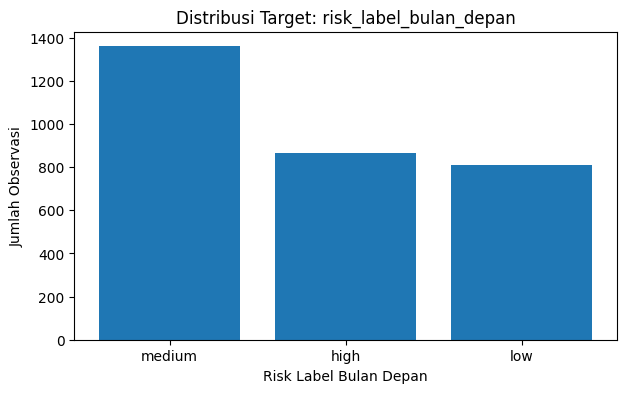

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(target_dist['risk_label_bulan_depan'], target_dist['jumlah'])
plt.title('Distribusi Target: risk_label_bulan_depan')
plt.xlabel('Risk Label Bulan Depan')
plt.ylabel('Jumlah Observasi')
plt.show()

## 4. Menentukan Fitur Input

Fitur input dipilih dari tiga kelompok:

1. **Fitur iklim bulan berjalan**
   - hujan, HTH, KAT, sifat hujan, dan skor iklim.

2. **Fitur sensitivitas historis wilayah**
   - historical_score, freq_penurunan, volatilitas.

3. **Fitur temporal**
   - lag 1 bulan dan rolling average 3 bulan.

Kolom yang tidak boleh menjadi input:
- `risk_label_bulan_depan` karena itu target,
- `final_score_bulan_depan` karena itu informasi masa depan,
- `rekomendasi_aksi` karena ini turunan dari label,
- `faktor_dominan` karena ini turunan dari skor,
- output/label yang sudah terlalu dekat dengan target masa depan.

In [ ]:
numeric_features = [
    'bulan',
    'hujan_mm',
    'rasio_hujan_terhadap_normal',
    'HTH_hari',
    'rasio_KAT_terhadap_normal',
    'hujan_score',
    'HTH_score',
    'KAT_score',
    'climate_score',
    'historical_score',
    'freq_penurunan',
    'volatilitas',
    'hujan_mm_lag1',
    'hujan_mm_roll3',
    'rasio_hujan_terhadap_normal_lag1',
    'rasio_hujan_terhadap_normal_roll3',
    'HTH_hari_lag1',
    'HTH_hari_roll3',
    'rasio_KAT_terhadap_normal_lag1',
    'rasio_KAT_terhadap_normal_roll3',
    'climate_score_lag1',
    'climate_score_roll3'
]

categorical_features = [
    'wilayah',
    'sifat_hujan'
]

features = numeric_features + categorical_features

missing_cols = [col for col in features + [target, 'tahun'] if col not in modeling_table.columns]

if missing_cols:
    raise ValueError(f"Kolom berikut tidak ditemukan di modeling_table: {missing_cols}")

X = modeling_table[features]
y = modeling_table[target]

print("Jumlah fitur numerik:", len(numeric_features))
print("Jumlah fitur kategorikal:", len(categorical_features))
print("Total fitur:", len(features))
X.head()

Jumlah fitur numerik: 22
Jumlah fitur kategorikal: 2
Total fitur: 24


,bulan,hujan_mm,rasio_hujan_terhadap_normal,HTH_hari,rasio_KAT_terhadap_normal,hujan_score,HTH_score,KAT_score,climate_score,historical_score,freq_penurunan,volatilitas,hujan_mm_lag1,hujan_mm_roll3,rasio_hujan_terhadap_normal_lag1,rasio_hujan_terhadap_normal_roll3,HTH_hari_lag1,HTH_hari_roll3,rasio_KAT_terhadap_normal_lag1,rasio_KAT_terhadap_normal_roll3,climate_score_lag1,climate_score_roll3,wilayah,sifat_hujan
0,1,451.514587,1.350384,0,1.056056,0,0,0,0,2,0.428571,0.070316,NaN,451.514587,NaN,1.350384,NaN,0.0,NaN,1.056056,NaN,0.000000,BANGKALAN,AN
1,2,202.027545,0.806629,2,1.045244,2,0,0,2,2,0.428571,0.070316,451.514587,326.771066,1.350384,1.078506,0.0,1.0,1.056056,1.050650,0.0,1.000000,BANGKALAN,BN
2,3,227.062383,0.933576,1,1.043343,0,0,1,1,2,0.428571,0.070316,202.027545,293.534838,0.806629,1.030196,2.0,1.0,1.045244,1.048214,2.0,1.000000,BANGKALAN,N
3,4,97.913194,0.485514,3,1.021672,2,0,1,3,2,0.428571,0.070316,227.062383,175.667707,0.933576,0.741906,1.0,2.0,1.043343,1.036753,1.0,2.000000,BANGKALAN,BN
4,5,30.727801,0.266231,17,0.910004,2,2,2,6,2,0.428571,0.070316,97.913194,118.567793,0.485514,0.561773,3.0,7.0,1.021672,0.991673,3.0,3.333333,BANGKALAN,BN


## 5. Temporal Split

Karena PantauPadi adalah sistem early warning, evaluasi lebih realistis jika model dilatih pada data masa lalu dan diuji pada periode yang lebih baru.

Split yang digunakan:

```text
Train: 2018–2024
Test : 2025–2026
```

Ini lebih masuk akal daripada random split karena model seolah-olah benar-benar digunakan untuk memprediksi masa depan.

In [ ]:
train_data = modeling_table[modeling_table['tahun'] <= 2024].copy()
test_data = modeling_table[modeling_table['tahun'] >= 2025].copy()

X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nDistribusi target train:")
print(y_train.value_counts())

print("\nDistribusi target test:")
print(y_test.value_counts())

Train shape: (2604, 24)
Test shape: (434, 24)

Distribusi target train:
risk_label_bulan_depan
medium    1134
high       854
low        616
Name: count, dtype: int64

Distribusi target test:
risk_label_bulan_depan
medium    226
low       194
high       14
Name: count, dtype: int64


## 6. Preprocessing Pipeline

Pipeline preprocessing dibuat agar:
- missing value numerik diisi dengan median,
- missing value kategorikal diisi dengan modus,
- fitur numerik distandardisasi untuk Logistic Regression,
- fitur kategorikal seperti wilayah dan sifat_hujan diubah dengan One-Hot Encoding.

In [ ]:
numeric_transformer_lr = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

numeric_transformer_rf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess_lr = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_lr, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

preprocess_rf = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_rf, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## 7. Fungsi Evaluasi Model

Fungsi ini digunakan agar evaluasi Logistic Regression dan Random Forest konsisten.

In [ ]:
labels = ['low', 'medium', 'high']

def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')

    report = classification_report(y_true, y_pred, labels=labels, zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels,
        zero_division=0
    )

    metrics_df = pd.DataFrame({
        'label': labels,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'support': support
    })

    print("="*60)
    print(model_name)
    print("="*60)
    print("Accuracy:", round(accuracy, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("\nClassification Report:")
    print(report)
    print("\nConfusion Matrix [low, medium, high]:")
    print(cm)

    return {
        'model': model_name,
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'recall_high': metrics_df.loc[metrics_df['label'] == 'high', 'recall'].values[0],
        'f1_high': metrics_df.loc[metrics_df['label'] == 'high', 'f1_score'].values[0],
        'metrics_per_class': metrics_df,
        'confusion_matrix': cm
    }

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(range(len(labels)), labels)
    plt.yticks(range(len(labels)), labels)

    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.colorbar()
    plt.show()

## 8. Model 1 — Logistic Regression

Logistic Regression digunakan sebagai baseline machine learning.

Kelebihan:
- mudah dijelaskan,
- cocok sebagai baseline,
- performanya stabil untuk data tabular sederhana.

Logistic Regression
Accuracy: 0.7834
Macro F1: 0.6262

Classification Report:
              precision    recall  f1-score   support

         low       0.85      0.82      0.84       194
      medium       0.83      0.77      0.80       226
        high       0.17      0.43      0.24        14

    accuracy                           0.78       434
   macro avg       0.62      0.67      0.63       434
weighted avg       0.82      0.78      0.80       434


Confusion Matrix [low, medium, high]:
[[160  28   6]
 [ 29 174  23]
 [  0   8   6]]


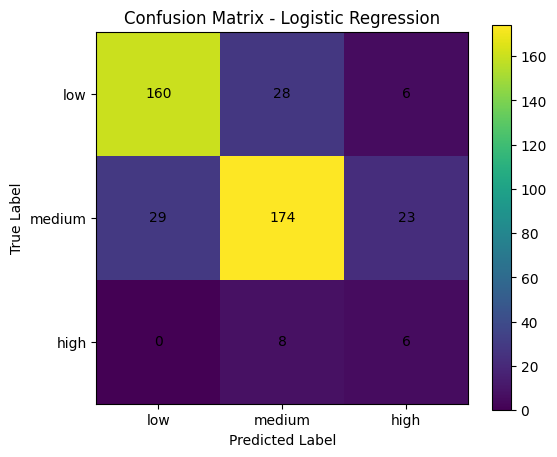

In [ ]:
logreg_model = Pipeline(steps=[
    ('preprocess', preprocess_lr),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

logreg_model.fit(X_train, y_train)
y_pred_logreg = logreg_model.predict(X_test)

logreg_result = evaluate_model("Logistic Regression", y_test, y_pred_logreg)
plot_confusion_matrix(logreg_result['confusion_matrix'], 'Confusion Matrix - Logistic Regression')

## 9. Model 2 — Random Forest

Random Forest digunakan sebagai model non-linear pembanding.

Kelebihan:
- bisa menangkap pola non-linear,
- tidak terlalu sensitif terhadap skala fitur,
- bisa memberikan feature importance.

Random Forest
Accuracy: 0.7926
Macro F1: 0.5447

Classification Report:
              precision    recall  f1-score   support

         low       0.84      0.81      0.83       194
      medium       0.79      0.82      0.81       226
        high       0.00      0.00      0.00        14

    accuracy                           0.79       434
   macro avg       0.54      0.55      0.54       434
weighted avg       0.79      0.79      0.79       434


Confusion Matrix [low, medium, high]:
[[158  35   1]
 [ 30 186  10]
 [  0  14   0]]


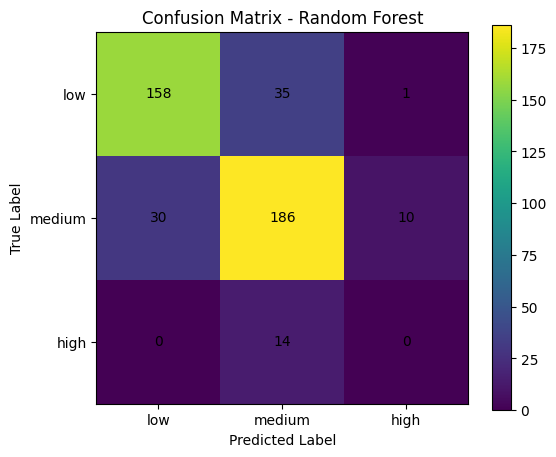

In [ ]:
rf_model = Pipeline(steps=[
    ('preprocess', preprocess_rf),
    ('model', RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight='balanced',
        min_samples_leaf=2
    ))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_result = evaluate_model("Random Forest", y_test, y_pred_rf)
plot_confusion_matrix(rf_result['confusion_matrix'], 'Confusion Matrix - Random Forest')

## 10. Perbandingan Model

Model dibandingkan berdasarkan:
- Accuracy,
- Macro F1,
- Recall kelas high,
- F1 kelas high.

Untuk sistem early warning, kelas `high` perlu diperhatikan karena berkaitan dengan prioritas pemantauan wilayah berisiko.

In [ ]:
comparison_df = pd.DataFrame([
    {
        'model': logreg_result['model'],
        'accuracy': logreg_result['accuracy'],
        'macro_f1': logreg_result['macro_f1'],
        'recall_high': logreg_result['recall_high'],
        'f1_high': logreg_result['f1_high']
    },
    {
        'model': rf_result['model'],
        'accuracy': rf_result['accuracy'],
        'macro_f1': rf_result['macro_f1'],
        'recall_high': rf_result['recall_high'],
        'f1_high': rf_result['f1_high']
    }
])

comparison_df.round(4)

,model,accuracy,macro_f1,recall_high,f1_high
0,Logistic Regression,0.7834,0.6262,0.4286,0.2449
1,Random Forest,0.7926,0.5447,0.0000,0.0000


In [ ]:
# Aturan sederhana pemilihan model:
# 1. Prioritaskan macro_f1.
# 2. Jika macro_f1 mirip, lihat recall_high.
# 3. Jika recall_high penting untuk early warning, model dengan recall_high lebih baik bisa dipilih.

comparison_sorted = comparison_df.sort_values(
    by=['macro_f1', 'recall_high', 'accuracy'],
    ascending=False
)

best_model_name = comparison_sorted.iloc[0]['model']

print("Model terbaik berdasarkan macro_f1, recall_high, dan accuracy:")
print(best_model_name)

comparison_sorted.round(4)

Model terbaik berdasarkan macro_f1, recall_high, dan accuracy:
Logistic Regression


,model,accuracy,macro_f1,recall_high,f1_high
0,Logistic Regression,0.7834,0.6262,0.4286,0.2449
1,Random Forest,0.7926,0.5447,0.0000,0.0000


## 11. Feature Importance Random Forest

Feature importance membantu membaca variabel apa yang paling banyak dipakai Random Forest dalam membedakan risiko bulan depan.

Catatan:
Feature importance bukan bukti sebab-akibat. Ini hanya menunjukkan kontribusi fitur dalam model.

In [ ]:
rf_clf = rf_model.named_steps['model']
preprocessor = rf_model.named_steps['preprocess']

cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, cat_feature_names])

feature_importance = pd.DataFrame({
    'feature': all_feature_names,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance.head(20)

,feature,importance
1,hujan_mm,0.076844
0,bulan,0.067802
15,rasio_hujan_terhadap_normal_roll3,0.067795
2,rasio_hujan_terhadap_normal,0.061154
4,rasio_KAT_terhadap_normal,0.058704
9,historical_score,0.052580
19,rasio_KAT_terhadap_normal_roll3,0.050810
13,hujan_mm_roll3,0.050051
18,rasio_KAT_terhadap_normal_lag1,0.047683
14,rasio_hujan_terhadap_normal_lag1,0.046641


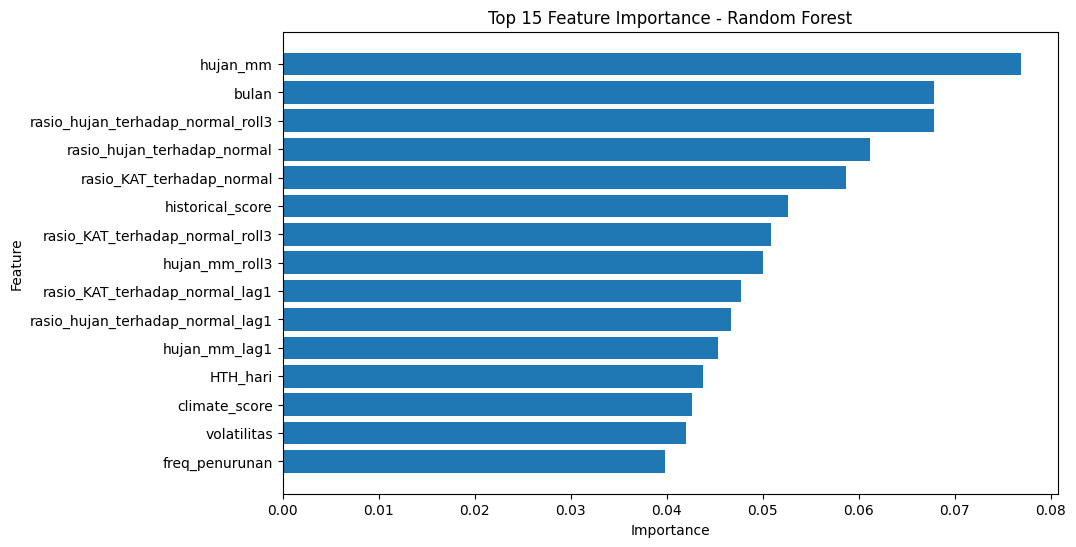

In [ ]:
top_importance = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_importance['feature'][::-1], top_importance['importance'][::-1])
plt.title('Top 15 Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## 12. Narasi Evaluasi Model


`
Modeling dilakukan untuk memprediksi risk_label_bulan_depan dengan menggunakan temporal split, yaitu data 2018–2024 sebagai train dan 2025–2026 sebagai test. Pendekatan ini dipilih agar evaluasi lebih realistis karena model dilatih menggunakan data historis dan diuji pada periode yang lebih baru.

Logistic Regression digunakan sebagai baseline machine learning, sedangkan Random Forest digunakan sebagai model non-linear pembanding. Model dievaluasi menggunakan accuracy, macro F1-score, recall kelas high, dan confusion matrix.

Dalam konteks early warning, performa model tidak hanya dilihat dari accuracy, tetapi juga dari kemampuan mengenali kelas high risk. Hal ini penting karena kelas high berkaitan dengan wilayah yang perlu diprioritaskan untuk pemantauan lapangan.
```

## 13. Train Final Model

In [ ]:

selected_model_name = 'Logistic Regression'

if selected_model_name == 'Logistic Regression':
    final_model = Pipeline(steps=[
        ('preprocess', preprocess_lr)
        ('model', LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            random_state=42
        ))
    ])
else:
    final_model = Pipeline(steps=[
        ('preprocess', preprocess_rf),
        ('model', RandomForestClassifier(
            n_estimators=400,
            random_state=42,
            class_weight='balanced',
            min_samples_leaf=2
        ))
    ])

final_model.fit(X, y)

print("Final model trained:", selected_model_name)

Final model trained: Logistic Regression


## 14. Prediksi Risiko Bulan Depan untuk Data Terbaru 2026

In [ ]:
latest_path = 'pantaupadi_latest_risk_2026_final.csv'

if not os.path.exists(latest_path):
    try:
        from google.colab import files
        print("File pantaupadi_latest_risk_2026_final.csv belum ditemukan. Silakan upload file tersebut.")
        uploaded = files.upload()
        if 'pantaupadi_latest_risk_2026_final.csv' in uploaded:
            latest_path = '/content/pantaupadi_latest_risk_2026_final.csv'
        else:
            latest_path = '/content/' + list(uploaded.keys())[0]
            print("Menggunakan file:", latest_path)
    except Exception as e:
        raise FileNotFoundError("File latest 2026 tidak ditemukan. Pastikan file sudah diupload ke /content.") from e

latest_2026 = pd.read_csv(latest_path)

if 'tanggal' in latest_2026.columns:
    latest_2026['tanggal'] = pd.to_datetime(latest_2026['tanggal'])

print("Shape latest 2026:", latest_2026.shape)
latest_2026.head()

Shape latest 2026: (93, 37)


,wilayah,tahun,bulan,hujan_mm,HTH_hari,hujan_normal_mm,rasio_hujan_terhadap_normal,sifat_hujan,KAT_value,KAT_normal,rasio_KAT_terhadap_normal,produksi_padi_bulanan,luas_panen_bulanan,tanggal,hujan_score,HTH_score,KAT_score,climate_score,freq_penurunan,volatilitas,historical_score,final_score,risk_label,risk_label_bulan_depan,final_score_bulan_depan,hujan_mm_lag1,hujan_mm_roll3,rasio_hujan_terhadap_normal_lag1,rasio_hujan_terhadap_normal_roll3,HTH_hari_lag1,HTH_hari_roll3,rasio_KAT_terhadap_normal_lag1,rasio_KAT_terhadap_normal_roll3,climate_score_lag1,climate_score_roll3,faktor_dominan,rekomendasi_aksi
0,BANGKALAN,2026,1,340.456743,2,334.360256,1.018233,N,376.823232,371.607650,1.015650,0.0,0.0,2026-01-01,0,0,1,1,0.428571,0.070316,2,3,medium,medium,3.0,310.392105,313.117707,1.141924,1.493580,1.0,1.333333,1.169730,1.224729,0.0,0.333333,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...
1,BANGKALAN,2026,2,304.352251,2,250.459204,1.215177,AN,373.171828,378.690230,0.986413,0.0,0.0,2026-02-01,0,0,1,1,0.428571,0.070316,2,3,medium,medium,3.0,340.456743,318.400366,1.018233,1.125111,2.0,1.666667,1.015650,1.057264,1.0,0.666667,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...
2,BANGKALAN,2026,3,260.971227,3,243.218011,1.072993,N,365.890293,378.722207,0.967354,0.0,0.0,2026-03-01,0,0,1,1,0.428571,0.070316,2,3,medium,NaN,NaN,304.352251,301.926740,1.215177,1.102134,2.0,2.333333,0.986413,0.989805,1.0,1.000000,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...
3,BANYUWANGI,2026,1,370.498434,2,304.503003,1.216732,AN,586.092919,489.972819,1.098460,0.0,0.0,2026-01-01,0,0,0,0,0.428571,0.087079,2,2,low,low,2.0,327.401054,379.336898,1.089710,1.517512,3.0,2.000000,1.242011,1.231420,0.0,0.000000,Sensitivitas historis wilayah,Pantau rutin; belum membutuhkan intervensi pri...
4,BANYUWANGI,2026,2,486.876657,1,307.129178,1.585250,AN,612.669092,533.223844,1.083517,0.0,0.0,2026-02-01,0,0,0,0,0.428571,0.087079,2,2,low,medium,4.0,370.498434,394.925382,1.216732,1.297231,2.0,2.000000,1.098460,1.141330,0.0,0.000000,Sensitivitas historis wilayah,Pantau rutin; belum membutuhkan intervensi pri...


In [ ]:
latest_max_month = latest_2026['bulan'].max()

latest_for_prediction = latest_2026[latest_2026['bulan'] == latest_max_month].copy()

# Pastikan semua fitur tersedia
missing_latest_cols = [col for col in features if col not in latest_for_prediction.columns]
if missing_latest_cols:
    raise ValueError(f"Kolom berikut tidak ditemukan di latest_2026: {missing_latest_cols}")

X_latest = latest_for_prediction[features]

latest_for_prediction['prediksi_risk_label_bulan_depan'] = final_model.predict(X_latest)

prediction_output_cols = [
    'wilayah',
    'tahun',
    'bulan',
    'risk_label',
    'final_score',
    'climate_score',
    'historical_score',
    'sifat_hujan',
    'HTH_hari',
    'rasio_KAT_terhadap_normal',
    'faktor_dominan',
    'rekomendasi_aksi',
    'prediksi_risk_label_bulan_depan'
]

available_output_cols = [col for col in prediction_output_cols if col in latest_for_prediction.columns]

prediction_output = latest_for_prediction[available_output_cols].copy()

print("Bulan terbaru yang dipakai untuk prediksi:", latest_max_month)
prediction_output.head(20)

Bulan terbaru yang dipakai untuk prediksi: 3


,wilayah,tahun,bulan,risk_label,final_score,climate_score,historical_score,sifat_hujan,HTH_hari,rasio_KAT_terhadap_normal,faktor_dominan,rekomendasi_aksi,prediksi_risk_label_bulan_depan
2,BANGKALAN,2026,3,medium,3,1,2,N,3,0.967354,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,medium
5,BANYUWANGI,2026,3,medium,4,2,2,N,4,1.030853,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,medium
8,BATU,2026,3,medium,3,1,2,AN,3,0.965766,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,medium
11,BLITAR,2026,3,medium,3,1,2,N,3,1.016676,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,medium
14,BOJONEGORO,2026,3,low,2,1,1,N,1,0.982019,"Ketersediaan air rendah, Sensitivitas historis...",Pantau rutin; belum membutuhkan intervensi pri...,low
17,BONDOWOSO,2026,3,low,1,1,0,AN,4,1.050922,HTH panjang,Pantau rutin; belum membutuhkan intervensi pri...,low
20,GRESIK,2026,3,medium,3,1,2,N,1,0.993438,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,medium
23,JEMBER,2026,3,low,2,2,0,N,6,1.039947,"HTH panjang, Ketersediaan air rendah",Pantau rutin; belum membutuhkan intervensi pri...,low
26,JOMBANG,2026,3,low,1,1,0,N,2,0.991928,Ketersediaan air rendah,Pantau rutin; belum membutuhkan intervensi pri...,low
29,KEDIRI,2026,3,medium,3,1,2,N,2,1.002023,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,medium


In [ ]:
pred_dist = (
    prediction_output['prediksi_risk_label_bulan_depan']
    .value_counts()
    .reset_index()
)

pred_dist.columns = ['prediksi_risk_label_bulan_depan', 'jumlah']
pred_dist['persentase'] = (pred_dist['jumlah'] / pred_dist['jumlah'].sum() * 100).round(2)

pred_dist

,prediksi_risk_label_bulan_depan,jumlah,persentase
0,medium,19,61.29
1,low,12,38.71


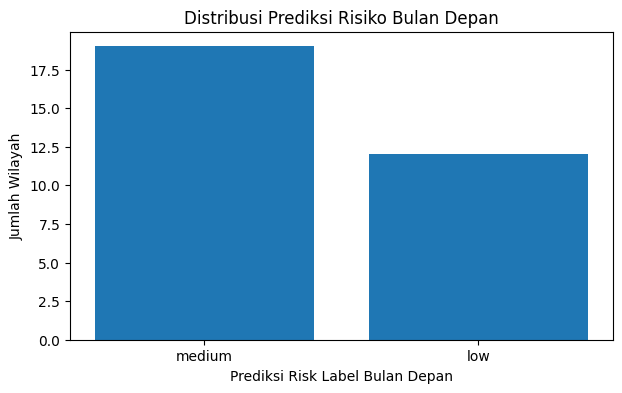

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(pred_dist['prediksi_risk_label_bulan_depan'], pred_dist['jumlah'])
plt.title('Distribusi Prediksi Risiko Bulan Depan')
plt.xlabel('Prediksi Risk Label Bulan Depan')
plt.ylabel('Jumlah Wilayah')
plt.show()

## 15. Export Hasil Prediksi

File output ini dapat digunakan untuk dashboard atau bahan presentasi.

In [ ]:
output_path = 'pantaupadi_prediksi_bulan_depan_2026.csv'
prediction_output.to_csv(output_path, index=False)

print("File berhasil disimpan:", output_path)
prediction_output.head()

File berhasil disimpan: pantaupadi_prediksi_bulan_depan_2026.csv


,wilayah,tahun,bulan,risk_label,final_score,climate_score,historical_score,sifat_hujan,HTH_hari,rasio_KAT_terhadap_normal,faktor_dominan,rekomendasi_aksi,prediksi_risk_label_bulan_depan
2,BANGKALAN,2026,3,medium,3,1,2,N,3,0.967354,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,medium
5,BANYUWANGI,2026,3,medium,4,2,2,N,4,1.030853,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,medium
8,BATU,2026,3,medium,3,1,2,AN,3,0.965766,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,medium
11,BLITAR,2026,3,medium,3,1,2,N,3,1.016676,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...,medium
14,BOJONEGORO,2026,3,low,2,1,1,N,1,0.982019,"Ketersediaan air rendah, Sensitivitas historis...",Pantau rutin; belum membutuhkan intervensi pri...,low
